# Data Cleaning

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
# Update these paths to match your folder structure
DATA_DIR = "C:/Users/Gorata/IndabaX/Data_Raw" # folder containing the 5 CSV files

In [5]:
# Function for changing date format
def add_ym(df):
    df = df.copy()
    df["year_month"] = df["Date"].dt.to_period("M").astype(str)
    return df

## 1. Baltic Dry Index

In [6]:
# Load Baltic Dry Index Dataset
bdi = pd.read_csv(f"{DATA_DIR}/01_baltic_dry_index_daily.csv", parse_dates=["Date"])

In [7]:
bdi.head()

,Date,BDI_Close,BDI_High,BDI_Low
0,2000-01-04,1320,1320,1320
1,2000-01-05,1329,1329,1329
2,2000-01-06,1351,1351,1351
3,2000-01-07,1368,1368,1368
4,2000-01-10,1376,1376,1376


In [8]:
bdi.tail()

,Date,BDI_Close,BDI_High,BDI_Low
5987,2023-12-18,2288,2288,2288
5988,2023-12-19,2219,2219,2219
5989,2023-12-20,2150,2150,2150
5990,2023-12-21,2087,2087,2087
5991,2023-12-22,2094,2094,2094


In [9]:
# Check dimensions of data
bdi.shape

(5992, 4)

In [10]:
# Check structure
bdi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5992 entries, 0 to 5991
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       5992 non-null   datetime64[ns]
 1   BDI_Close  5992 non-null   int64         
 2   BDI_High   5992 non-null   int64         
 3   BDI_Low    5992 non-null   int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 187.4 KB


No null values

In [11]:
# Check date range
print(f"Date range: {bdi['Date'].min().date()} to {bdi['Date'].max().date()}")

Date range: 2000-01-04 to 2023-12-22


In [12]:
# Check for duplicate rows
bdi.duplicated().sum()

3

In [13]:
# Drop duplicates
bdi = bdi.drop_duplicates()

In [14]:
# Check new dimensions
bdi.shape

(5989, 4)

In [15]:
# Check if dates are sorted
bdi['Date'].is_monotonic_increasing # Checks if dates are in ascending order. Returns "True" if this is the case.

True

In [16]:
# Check for duplicate dates
bdi['Date'].duplicated().sum()

0

In [17]:
# Summary statistics
bdi.describe()

,BDI_Close,BDI_High,BDI_Low
count,5989.000000,5989.000000,5989.000000
mean,2244.805978,2244.613959,2244.549507
std,1931.535463,1931.728391,1931.725691
min,290.000000,0.000000,0.000000
25%,1025.000000,1025.000000,1025.000000
50%,1559.000000,1559.000000,1559.000000
75%,2696.000000,2696.000000,2696.000000
max,11793.000000,11793.000000,11793.000000


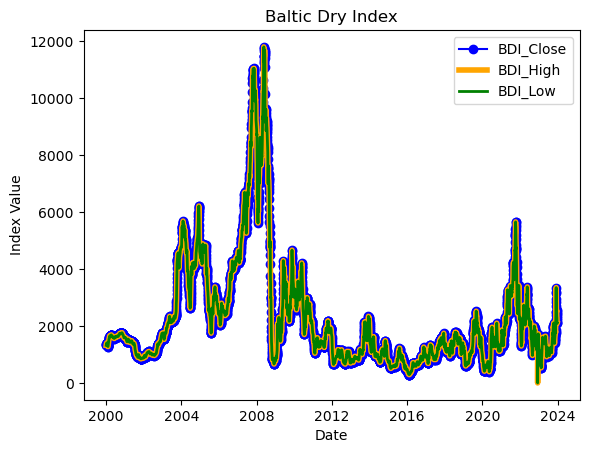

In [18]:
# Plot the time series
fig, ax = plt.subplots()

ax.plot(bdi['Date'], bdi['BDI_Close'], label='BDI_Close', color='blue', marker='o')
ax.plot(bdi['Date'], bdi['BDI_High'], label='BDI_High', color='orange', linewidth=4)
ax.plot(bdi['Date'], bdi['BDI_Low'], label='BDI_Low', color='green', linewidth=2)

ax.set_title('Baltic Dry Index')
ax.set_xlabel('Date')
ax.set_ylabel('Index Value')
ax.legend()  # Displays the labels assigned above

plt.show()

## 2. Brent Crude Oil Prices

In [19]:
# Load Brent Crude Oil prices dataset
brent = pd.read_csv(f"{DATA_DIR}/02_brent_crude_monthly.csv", parse_dates=["Date"])

In [20]:
brent.head()

,Date,Brent_USD_per_barrel
0,2000-01-15,25.51
1,2000-02-15,27.78
2,2000-03-15,27.49
3,2000-04-15,22.76
4,2000-05-15,27.74


In [21]:
brent.tail()

,Date,Brent_USD_per_barrel
283,2023-08-15,86.15
284,2023-09-15,93.72
285,2023-10-15,90.60
286,2023-11-15,82.94
287,2023-12-15,77.63


In [22]:
# Check dimensions of data
brent.shape

(288, 2)

In [23]:
# Check structure of data
brent.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  288 non-null    datetime64[ns]
 1   Brent_USD_per_barrel  288 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.6 KB


No null values

In [24]:
# Check date range
print(f"Date range: {brent['Date'].min().date()} to {brent['Date'].max().date()}")

Date range: 2000-01-15 to 2023-12-15


In [25]:
# Check for duplicate rows
brent.duplicated().sum()

0

In [26]:
# Check if dates are sorted
brent['Date'].is_monotonic_increasing # Checks if dates are in ascending order. Returns "True" if this is the case.

True

In [27]:
# Check for duplicate dates
brent['Date'].duplicated().sum()

0

In [28]:
# Summary statistics
brent.describe()

,Brent_USD_per_barrel
count,288.000000
mean,66.114792
std,29.208779
min,18.380000
25%,43.230000
50%,63.940000
75%,85.497500
max,132.720000


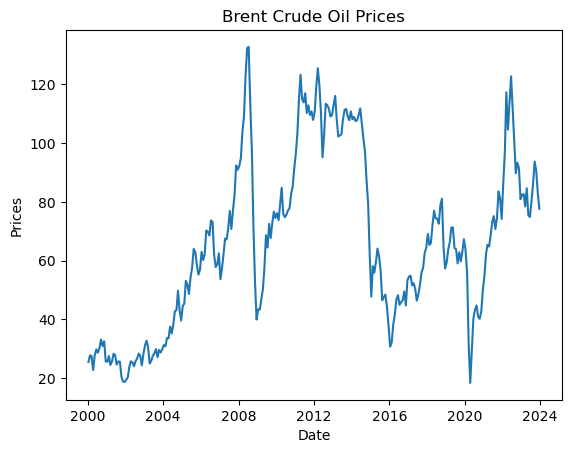

In [29]:
# Plot the time series
fig, ax = plt.subplots()

ax.plot(brent["Date"], brent["Brent_USD_per_barrel"])

ax.set_title("Brent Crude Oil Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Prices")

plt.show()

The crude oil prices show sharp spikes around the 2008 recession and the COVID-19 pandemic.

## 3. Botswana Policy Rate

In [30]:
# Load policy rate dataset
pr = pd.read_csv(f"{DATA_DIR}/03_botswana_policy_rate.csv", parse_dates=["Date"])

In [31]:
pr.head()

,Date,policy_rate
0,2000-01-01,14.0
1,2000-02-01,14.0
2,2000-03-01,14.0
3,2000-04-01,14.0
4,2000-05-01,14.0


In [32]:
pr.tail()

,Date,policy_rate
283,2023-08-01,2.65
284,2023-09-01,2.65
285,2023-10-01,2.65
286,2023-11-01,2.65
287,2023-12-01,2.65


In [33]:
# Check dimensions
pr.shape

(288, 2)

In [34]:
# Check structure
pr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         288 non-null    datetime64[ns]
 1   policy_rate  288 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.6 KB


No null values.

In [35]:
# Check date range
print(f"Date range: {pr['Date'].min().date()} to {pr['Date'].max().date()}")

Date range: 2000-01-01 to 2023-12-01


In [36]:
# Check for duplicate rows
pr.duplicated().sum()

0

In [37]:
# Check if dates are sorted
pr['Date'].is_monotonic_increasing # Checks if dates are in ascending order. Returns "True" if this is the case.

True

In [38]:
# Check for duplicate dates
pr['Date'].duplicated().sum()

0

In [39]:
# Summary statistics
pr.describe()

,policy_rate
count,288.000000
mean,11.586285
std,2.467477
min,1.650000
25%,12.000000
50%,12.000000
75%,12.000000
max,14.000000


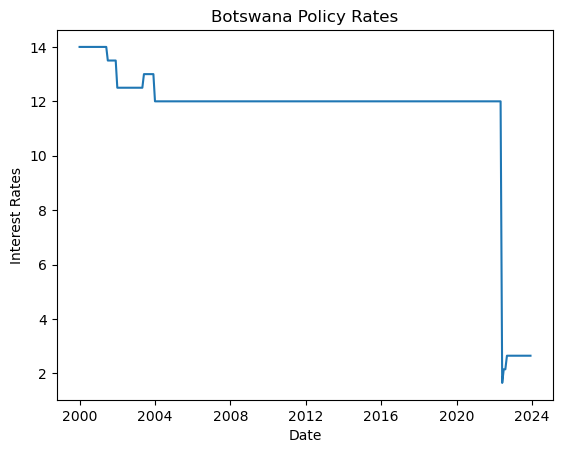

In [40]:
# Plot the time series
fig, ax = plt.subplots()

ax.plot(pr["Date"], pr["policy_rate"])

ax.set_title("Botswana Policy Rates")
ax.set_xlabel("Date")
ax.set_ylabel("Interest Rates")

plt.show()

The interest rate will likely not be a reliable indicator as it is fairly constant over the years.

## 4. FAO Botswana Prices

In [41]:
# Load food price dataset
fao = pd.read_csv(f"{DATA_DIR}/04_fao_botswana_prices.csv", parse_dates=["Date"])

In [42]:
fao.head()

,Date,Item Code,Item,Value
0,2000-01-01,23012,"Consumer Prices, General Indices (2015 = 100)",31.748320
1,2000-01-01,23013,"Consumer Prices, Food Indices (2015 = 100)",31.912372
2,2000-02-01,23012,"Consumer Prices, General Indices (2015 = 100)",31.974914
3,2000-02-01,23013,"Consumer Prices, Food Indices (2015 = 100)",32.163038
4,2000-03-01,23012,"Consumer Prices, General Indices (2015 = 100)",32.277040


In [43]:
fao.tail()

,Date,Item Code,Item,Value
847,2023-11-01,23013,"Consumer Prices, Food Indices (2015 = 100)",148.982852
848,2023-11-01,23014,Food price inflation,7.261119
849,2023-12-01,23012,"Consumer Prices, General Indices (2015 = 100)",146.861601
850,2023-12-01,23013,"Consumer Prices, Food Indices (2015 = 100)",149.353957
851,2023-12-01,23014,Food price inflation,6.077058


In [44]:
# Pivot FAO long → wide
fao_m = add_ym(fao)
fao_m["col"] = "FAO_" + fao_m["Item Code"].astype(str)
fao_wide = fao_m.pivot_table(index="year_month", columns="col", values="Value", aggfunc="first").reset_index()
fao_wide.columns.name = None

In [45]:
fao_wide.head()

,year_month,FAO_23012,FAO_23013,FAO_23014
0,2000-01,31.748320,31.912372,NaN
1,2000-02,31.974914,32.163038,NaN
2,2000-03,32.277040,32.413704,NaN
3,2000-04,32.679873,32.612508,NaN
4,2000-05,32.881290,32.811312,NaN


In [46]:
# Check dimensions
fao_wide.shape

(288, 4)

In [47]:
# Check structure
fao_wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year_month  288 non-null    object 
 1   FAO_23012   288 non-null    float64
 2   FAO_23013   288 non-null    float64
 3   FAO_23014   276 non-null    float64
dtypes: float64(3), object(1)
memory usage: 9.1+ KB


In [50]:
fao_wide.head(20)

,year_month,FAO_23012,FAO_23013,FAO_23014
0,2000-01,31.748320,31.912372,NaN
1,2000-02,31.974914,32.163038,NaN
2,2000-03,32.277040,32.413704,NaN
3,2000-04,32.679873,32.612508,NaN
4,2000-05,32.881290,32.811312,NaN
5,2000-06,33.057530,33.010116,NaN
6,2000-07,33.535894,33.010116,NaN
7,2000-08,33.611426,33.010116,NaN
8,2000-09,33.712134,33.010116,NaN
9,2000-10,33.989082,32.992829,NaN


In [51]:
# Drop null values as they are duplicate months
fao_clean = fao_wide.dropna(subset=['FAO_23014'])

In [53]:
# Check structure
fao_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 276 entries, 12 to 287
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year_month  276 non-null    object 
 1   FAO_23012   276 non-null    float64
 2   FAO_23013   276 non-null    float64
 3   FAO_23014   276 non-null    float64
dtypes: float64(3), object(1)
memory usage: 10.8+ KB


In [57]:
# Check data type of year_month
fao_clean['year_month'].dtype

dtype('O')

In [54]:
# Check for duplicate rows
fao_clean.duplicated().sum()

0

In [58]:
# Check if year_month is sorted
fao_clean['year_month'].is_monotonic_increasing # Checks if year_month is in ascending order. Returns "True" if this is the case.

True

In [59]:
# Check for duplicate dates
fao_clean['year_month'].duplicated().sum()

0

In [60]:
# Summary statistics
fao_clean.describe()

,FAO_23012,FAO_23013,FAO_23014
count,276.000000,276.000000,276.000000
mean,84.406142,83.534631,6.855304
std,31.841912,31.774874,5.414045
min,34.291207,33.061978,-1.352657
25%,55.199055,50.713250,3.151178
50%,88.017776,91.361315,5.210525
75%,108.618562,106.100176,9.170462
max,146.861601,149.353957,25.089606


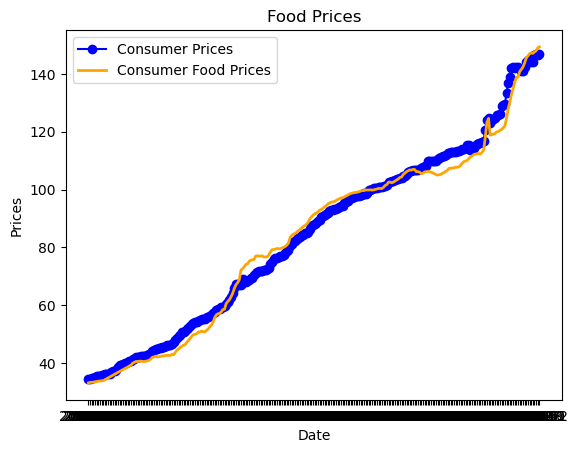

In [63]:
# Plot the time series
fig, ax = plt.subplots()

ax.plot(fao_clean['year_month'], fao_clean['FAO_23012'], label='Consumer Prices', color='blue', marker='o')
ax.plot(fao_clean['year_month'], fao_clean['FAO_23013'], label='Consumer Food Prices', color='orange', linewidth=2)

ax.set_title('Food Prices')
ax.set_xlabel('Date')
ax.set_ylabel('Prices')
ax.legend()  # Displays the labels assigned above

plt.show()

In [ ]:
# Plot the time series
fig, ax = plt.subplots()

ax.plot(fao_clean["year_month"], pr["FAO_23014"])

ax.set_title("Botswana Policy Rates")
ax.set_xlabel("Date")
ax.set_ylabel("Interest Rates")

plt.show()